# Train and evaluate machine learning models with experimental features

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
#!pip freeze > requirements.txt

In [3]:
!pip install optuna --quiet
!pip install optuna-integration[sklearn]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.5/98.5 kB 8.1 MB/s eta 0:00:00


In [15]:
# Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Utils
import warnings
import os
import json
import joblib

# Data Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from yellowbrick.model_selection import FeatureImportances
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA


# Model Selection & Validation
from sklearn.model_selection import train_test_split, cross_val_score

# Cross validation and hyperparameters
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_validate

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

# Pipeline & Imbalanced Data Handling
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import loguniform


# Natural Language Processing
import nltk

# Model Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc,
    RocCurveDisplay
)

# Feature Analysis
from sklearn.inspection import permutation_importance

# Options
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore", category=FutureWarning)

In [9]:
# Configurar conexion con google drive y con carpeta de google colab
from google.colab import drive
drive.mount('/content/drive')
workin_dir = '/content/drive/MyDrive/Colab Notebooks/Prediccion de Adiciones Proyectos de Infraestructura'
os.chdir(workin_dir)
# import sys
# Add the directory containing the .py file to the Python path
# sys.path.append(workin_dir) # Replace with the actual path if different

# Now you can import functions from your .py file
# from ml_pipeline import *

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Función de entrenamiento

In [16]:
def train_tuning_evaluate_model(
    X_train,
    y_train,
    model,
    model_name="Model",
    stage=None,
    param_suggest_dict=None,
    X_test=None,
    y_test=None,
    n_trials=50,
    cv=5,
    scoring='roc_auc',
    direction='maximize',
    timeout=None,
    resampling_strategy=None,
    resampling_ratio=None,
    numeric_features=None,
    categorical_features=None,
    random_state=42,
    n_jobs=-1,
    plot_tuning_history=False
):
    """
    Realiza el entrenamiento, optimización de hiperparámetros y evaluación para un modelo de clasificación utilizando Optuna,
    con manejo de características categóricas y numéricas, y múltiples opciones de balanceo.

    Parámetros:
    -----------
    X_train : DataFrame
        Datos de entrenamiento con características.
    y_train : Series
        Variable objetivo.
    model : estimator
        Modelo de clasificación de scikit-learn.
    param_suggest_dict : dict
        Diccionario con funciones de sugerencia para Optuna.
        Ejemplo: {
            'max_depth': lambda trial: trial.suggest_int('max_depth', 3, 10),
            'learning_rate': lambda trial: trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        }
    X_test : DataFrame, default=None
        Datos de prueba con características. Si es None, se utilizará X_train.
    y_test : Series, default=None
        Variable objetivo para los datos de prueba. Si es None, se utilizará y_train.
    n_trials : int, default=50
        Número de pruebas para Optuna.
    cv : int, default=5
        Número de folds para validación cruzada.
    scoring : str, default='roc_auc'
        Métrica para evaluar el rendimiento del modelo.
    direction : str, default='maximize'
        Dirección de optimización: 'maximize' o 'minimize'.
    timeout : int, default=None
        Tiempo límite para la optimización (en segundos).
    resampling_strategy : str, default=None
        Estrategia de resampling:
        - Oversampling: 'smote', 'adasyn', 'random_over'
        - Undersampling: 'random_under', 'cluster_centroids'
        - Combinadas: 'smotetomek', 'smoteenn'
        - None: sin resampling
    resampling_ratio : float, default=None
        Proporción de clases deseada después del resampling.
    numeric_features : list, default=None
        Lista de nombres de características numéricas.
    categorical_features : list, default=None
        Lista de nombres de características categóricas.
    random_state : int, default=42
        Semilla para reproducibilidad.
    n_jobs : int, default=-1
        Número de trabajos paralelos.

    Retorna:
    --------
    dict
        Diccionario con los siguientes elementos:
        - 'best_estimator': Mejor estimador encontrado.
        - 'best_params': Mejores parámetros encontrados.
        - 'best_score': Mejor puntaje obtenido.
        - 'metrics': Diccionario con métricas del mejor modelo.
        - 'study': Objeto estudio de Optuna.
        - 'importance': Importancia de los parámetros.
        - 'results_df': DataFrame con todos los resultados de las pruebas.
    """


    # Si no se especifican las características, inferirlas
    if numeric_features is None and categorical_features is None:
        numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
        categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()



    # Crear transformadores para cada tipo de característica
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95))
    ])

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Preprocesamiento de características
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

    # Configurar el resampling según la estrategia seleccionada
    resampler = None
    if resampling_strategy:
        if resampling_ratio is None:
            resampling_ratio = 'auto'

        # Estrategias de oversampling
        if resampling_strategy == 'smote':
            resampler = SMOTE(sampling_strategy=resampling_ratio, random_state=random_state)
        elif resampling_strategy == 'adasyn':
            resampler = ADASYN(sampling_strategy=resampling_ratio, random_state=random_state)
        elif resampling_strategy == 'random_over':
            resampler = RandomOverSampler(sampling_strategy=resampling_ratio, random_state=random_state)

        # Estrategias de undersampling
        elif resampling_strategy == 'random_under':
            resampler = RandomUnderSampler(sampling_strategy=resampling_ratio, random_state=random_state)
        elif resampling_strategy == 'cluster_centroids':
            resampler = ClusterCentroids(sampling_strategy=resampling_ratio, random_state=random_state)

        # Estrategias combinadas
        elif resampling_strategy == 'smotetomek':
            resampler = SMOTETomek(sampling_strategy=resampling_ratio, random_state=random_state)
        elif resampling_strategy == 'smoteenn':
            resampler = SMOTEENN(sampling_strategy=resampling_ratio, random_state=random_state)

    # Crear base pipeline para ser clonada en cada trial
    if resampler:
        base_pipeline = ImbPipeline([
            ('preprocessor', preprocessor),
            ('resampler', resampler),
            ('classifier', model)
        ])
    else:
        base_pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])

    # Manejar X_test e y_test cuando son None
    if X_test is None:
        X_test = X_train
    if y_test is None:
        y_test = y_train

    # Configurar validación cruzada estratificada
    stratified_cv = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)

    # Definir función objetivo para Optuna
    def objective(trial):
        # Clonar el modelo base para este trial
        pipeline = clone(base_pipeline)

        # Aplicar las funciones de sugerencia de parámetros
        params = {}
        for param_name, suggest_func in param_suggest_dict.items():
            params[param_name] = suggest_func(trial)

        # Configurar el modelo con los parámetros sugeridos
        for param_name, param_value in params.items():
            setattr(pipeline.named_steps['classifier'], param_name, param_value)

        # Evaluar el modelo con validación cruzada
        try:
            scores = cross_val_score(
                pipeline,
                X_train,
                y_train,
                scoring=scoring,
                cv=stratified_cv,
                n_jobs=n_jobs
            )
            return np.mean(scores)
        except Exception as e:
            # Manejar errores y asignar un valor punitivo
            print(f"Error en trial {trial.number}: {str(e)}")
            return float('-inf') if direction == 'maximize' else float('inf')

    # Crear el estudio de Optuna
    study = optuna.create_study(
        direction=direction,
        sampler=optuna.samplers.TPESampler(seed=random_state)
    )

    # Ejecutar la optimización
    study.optimize(
        objective,
        n_trials=n_trials,
        timeout=timeout,
        n_jobs=1,  # Ya usamos paralelismo en cross_val_score
        show_progress_bar=True
    )

    # Obtener los mejores parámetros
    best_params = study.best_params
    best_score = study.best_value

    # Aplicar los mejores parámetros al modelo
    best_pipeline = clone(base_pipeline)
    for param_name, param_value in best_params.items():
        setattr(best_pipeline.named_steps['classifier'], param_name, param_value)

    # Entrenar el modelo con los mejores parámetros
    best_pipeline.fit(X_train, y_train)

    # Hacer predicciones
    y_pred = best_pipeline.predict(X_test)
    try:
        y_prob = best_pipeline.predict_proba(X_test)[:, 1]
    except (AttributeError, IndexError):
        # Si el modelo no tiene predict_proba o solo tiene una clase
        y_prob = None

    # Calcular métricas
    metrics = {
        'model': model_name,
        'stage': stage,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }

    # Añadir ROC AUC si es posible
    if y_prob is not None:
        metrics['roc_auc'] = roc_auc_score(y_test, y_prob)

    # Obtener importancia de parámetros
    try:
        importance = optuna.importance.get_param_importances(study)
    except:
        importance = {}
        print("No se pudo calcular la importancia de los parámetros")

    # Crear DataFrame con los resultados de las pruebas
    results_df = study.trials_dataframe()

    # Generar un reporte del tuning
    print(f"\n===== {model_name} Tuning Report in {stage} =====")
    print(f"Best {scoring}: {best_score:.4f}")
    print("\nBest parameters:")
    for param, value in best_params.items():
        print(f"- {param}: {value}")
    print("\nParameter importance:")
    for param, importance in importance.items():
        print(f"- {param}: {importance:.4f}")

    # Gráfico de historia de optimización
    if plot_tuning_history:
        plt.figure(figsize=(5, 3))
        optuna.visualization.matplotlib.plot_optimization_history(study, target_name=scoring)
        plt.title("Optimization History")
        plt.tight_layout()
        plt.show()

    # Generar un informe del desempeño
    print(f"\n===== {model_name} Performance Report =====")
    print("\nTest Set Metrics:")
    for metric, value in metrics.items():
        if metric not in ['model', 'stage']:
            print(f"- {metric}: {value:.4f}")



    return {
        'best_estimator': best_pipeline,
        'best_params': best_params,
        'best_score': best_score,
        'metrics': metrics,
        'study': study,
        'importance': importance,
        'results_df': results_df
    }


In [6]:
# Load list of columns
with open('Data/projectsColumns.txt', 'r') as f:
    projectsColumns = f.read().splitlines()
with open('Data/ownerColumns.txt', 'r') as f:
    ownerColumns = f.read().splitlines()
with open('Data/contractorColumns.txt', 'r') as f:
    contractorColumns = f.read().splitlines()
with open('Data/terridataColumns.txt', 'r') as f:
    terridataColumns = f.read().splitlines()
with open('Data/outcomeColumns.txt', 'r') as f:
    outcomeColumns = f.read().splitlines()

In [7]:
df = pd.read_csv('Data/trainData.csv')   # Load the data
df = df[(df['contractValueMw(G1)'] >= 1e3) & (df['totalCumContracts(G2)'] >= 5)].copy().reset_index()  # Filter out rows with contractValueMw(G1) <= 1000
#df = df[df['totalCumContracts(G2)'] >= 10].copy().reset_index()  # Filter out rows with contractValueMw(G1) <= 1000
df.drop(columns=['index'], inplace=True)
df.info()
# convert contractMonthSigned(G2) and contractMonthStart(G2) to object
#df['contractMonthSigned(G2)'] = df['contractMonthSigned(G2)'].astype(str)
#df['contractMonthStart(G2)'] = df['contractMonthStart(G2)'].astype(str)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4538 entries, 0 to 4537
Data columns (total 49 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   uid                                    4538 non-null   object 
 1   buyerName                              4538 non-null   object 
 2   buyerId                                4538 non-null   object 
 3   contractYearSigned                     4538 non-null   int64  
 4   contractValueMw(G1)                    4538 non-null   float64
 5   contractDurationDays(G1)               4538 non-null   float64
 6   projectIntensityMw(G1)                 4538 non-null   float64
 7   workCategory(G1)                       4538 non-null   object 
 8   prebidValueMw(G1)                      4538 non-null   float64
 9   bidContractRatio(G1)                   4538 non-null   float64
 10  contractMethodType(G1)                 4538 non-null   object 
 11  cont

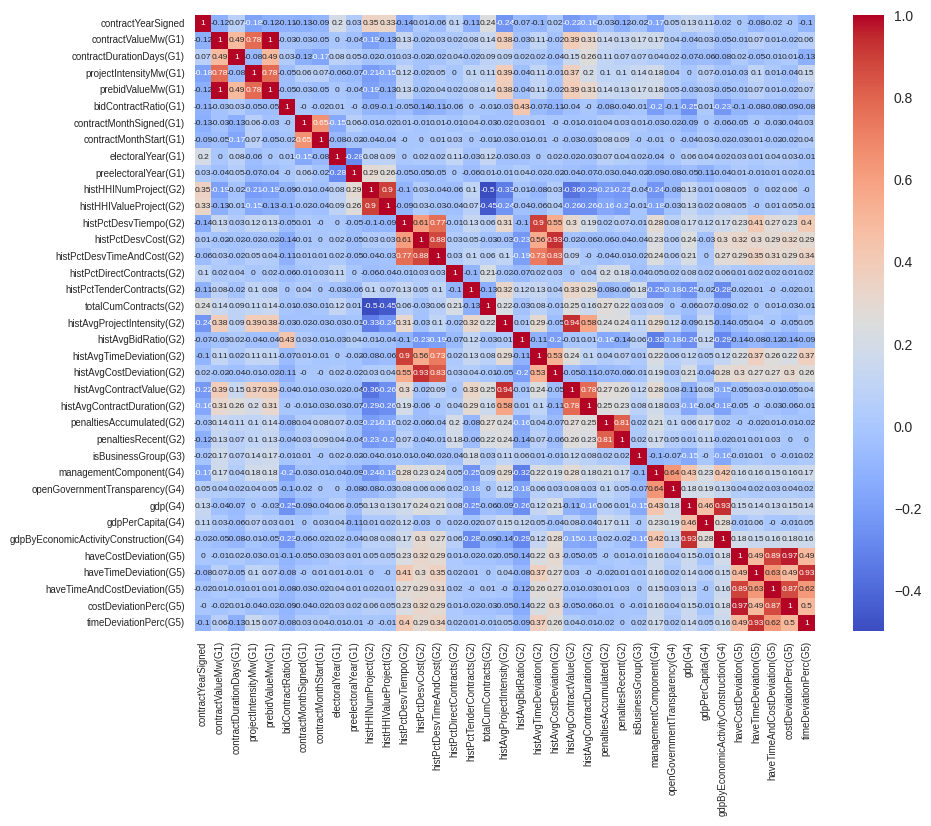

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(method='spearman').round(2),
           cmap='coolwarm',
           annot=True,
           annot_kws={'size': 6},
           xticklabels=True,  # Mostrar labels
           yticklabels=True)

# Configurar tamaño después
plt.xticks(fontsize=7)  # Tamaño y rotación eje X
plt.yticks(fontsize=7)
plt.show()

In [13]:
terridataColumns

['managementComponent(G4)',
 'openGovernmentTransparency(G4)',
 'gdp(G4)',
 'gdpPerCapita(G4)',
 'gdpByEconomicActivityConstruction(G4)']

In [14]:
projectsSizeVars = ['contractValueMw(G1)','contractDurationDays(G1)','projectIntensityMw(G1)','prebidValueMw(G1)']
marketConcetrationVars = ['histHHINumProject(G2)','histHHIValueProject(G2)']
ownerDeviationHist = ['histPctDesvTiempo(G2)','histPctDesvCost(G2)','histPctDesvTimeAndCost(G2)','histAvgTimeDeviation(G2)','histAvgCostDeviation(G2)']
terridataManagement = ['managementComponent(G4)','openGovernmentTransparency(G4)']
terridataDev = ['gdp(G4)','gdpPerCapita(G4)','gdpByEconomicActivityConstruction(G4)']

In [17]:
vars_s1 = projectsColumns
vars_s2 = projectsColumns + ownerColumns
vars_s3 = projectsColumns + contractorColumns
vars_s4 = projectsColumns + terridataColumns
vars_s5 = projectsColumns + ownerColumns + contractorColumns + terridataColumns
set_vars = [vars_s1, vars_s2, vars_s3, vars_s4, vars_s5]

In [18]:
# Definir el diccionario de sugerencias de parámetros para Optuna
param_suggest_dict_xgb = {
    'max_depth': lambda trial: trial.suggest_int('max_depth', 3, 20),
    'learning_rate': lambda trial: trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
    'n_estimators': lambda trial: trial.suggest_int('n_estimators', 50, 1000),
    'min_child_weight': lambda trial: trial.suggest_int('min_child_weight', 1, 10),
    'subsample': lambda trial: trial.suggest_float('subsample', 0.5, 1.0),
    'colsample_bytree': lambda trial: trial.suggest_float('colsample_bytree', 0.5, 1.0),
    'gamma': lambda trial: trial.suggest_float('gamma', 0, 10)
}

In [19]:
# Usar la función para optimizar el modelo
xgb_results = {}
for i in range(len(set_vars)):
  stage = 'S' + str(i+1)
  X = df[set_vars[i]]
  y = df['haveCostDeviation(G5)']
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
  # Definir el modelo base
  xgb_model = XGBClassifier(random_state=42)
  xgb_train_tuning_evaluate = train_tuning_evaluate_model(
      X_train=X_train,
      y_train=y_train,
      model=xgb_model,
      model_name='XGBoost',
      stage=stage,
      param_suggest_dict=param_suggest_dict_xgb,
      X_test=X_test,
      y_test=y_test,
      n_trials=30,  # Reducido para el ejemplo
      cv=5,          # Reducido para el ejemplo
      scoring='roc_auc',
      direction='maximize',
      timeout=None,
      resampling_strategy='smoteenn',  # Ejemplo con SMOTE
      random_state=42,
      plot_tuning_history=False
      )
  xgb_results[stage] = xgb_train_tuning_evaluate

[I 2025-06-04 22:34:32,260] A new study created in memory with name: no-name-00672570-0d6e-446a-be2a-d9527ec48c95


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-06-04 22:34:38,869] Trial 0 finished with value: 0.5433797167026244 and parameters: {'max_depth': 9, 'learning_rate': 0.2536999076681772, 'n_estimators': 746, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.5808361216819946}. Best is trial 0 with value: 0.5433797167026244.
[I 2025-06-04 22:34:40,527] Trial 1 finished with value: 0.5468411926727285 and parameters: {'max_depth': 18, 'learning_rate': 0.07725378389307355, 'n_estimators': 723, 'min_child_weight': 1, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'gamma': 2.1233911067827616}. Best is trial 1 with value: 0.5468411926727285.
[I 2025-06-04 22:34:42,260] Trial 2 finished with value: 0.5483857762168807 and parameters: {'max_depth': 6, 'learning_rate': 0.018659959624904916, 'n_estimators': 339, 'min_child_weight': 6, 'subsample': 0.7159725093210578, 'colsample_bytree': 0.645614570099021, 'gamma': 6.118528947223795}. Best is trial 2 with va

[I 2025-06-04 22:35:24,018] A new study created in memory with name: no-name-c959d442-54e7-42aa-934e-f2f36a819589



===== XGBoost Tuning Report in S1 =====
Best roc_auc: 0.5547

Best parameters:
- max_depth: 16
- learning_rate: 0.0504293792652915
- n_estimators: 455
- min_child_weight: 8
- subsample: 0.8285726521637806
- colsample_bytree: 0.8075588159360351
- gamma: 0.13179214380923376

Parameter importance:
- max_depth: 0.4365
- learning_rate: 0.1979
- gamma: 0.1839
- min_child_weight: 0.0806
- colsample_bytree: 0.0579
- subsample: 0.0230
- n_estimators: 0.0201

===== XGBoost Performance Report =====

Test Set Metrics:
- accuracy: 0.5345
- precision: 0.3623
- recall: 0.5503
- f1: 0.4369
- roc_auc: 0.5520


...

[I 2025-06-04 22:39:34,914] Trial 0 finished with value: 0.6101941630414451 and parameters: {'max_depth': 9, 'learning_rate': 0.2536999076681772, 'n_estimators': 746, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.5808361216819946}. Best is trial 0 with value: 0.6101941630414451.
[I 2025-06-04 22:39:38,357] Trial 1 finished with value: 0.6213705729128507 and parameters: {'max_depth': 18, 'learning_rate': 0.07725378389307355, 'n_estimators': 723, 'min_child_weight': 1, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'gamma': 2.1233911067827616}. Best is trial 1 with value: 0.6213705729128507.
[I 2025-06-04 22:39:40,014] Trial 2 finished with value: 0.6286598054663198 and parameters: {'max_depth': 6, 'learning_rate': 0.018659959624904916, 'n_estimators': 339, 'min_child_weight': 6, 'subsample': 0.7159725093210578, 'colsample_bytree': 0.645614570099021, 'gamma': 6.118528947223795}. Best is trial 2 with va

[I 2025-06-04 22:40:21,952] A new study created in memory with name: no-name-9994d1eb-99f7-405e-b244-e6d4f9c9c0ba



===== XGBoost Tuning Report in S4 =====
Best roc_auc: 0.6300

Best parameters:
- max_depth: 20
- learning_rate: 0.04016074146262433
- n_estimators: 54
- min_child_weight: 8
- subsample: 0.7792623653896451
- colsample_bytree: 0.5194708219512003
- gamma: 3.26739627443276

Parameter importance:
- learning_rate: 0.5068
- subsample: 0.2326
- n_estimators: 0.1114
- min_child_weight: 0.0922
- gamma: 0.0264
- max_depth: 0.0161
- colsample_bytree: 0.0146

===== XGBoost Performance Report =====

Test Set Metrics:
- accuracy: 0.5198
- precision: 0.3869
- recall: 0.7919
- f1: 0.5198
- roc_auc: 0.6397


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-06-04 22:40:28,891] Trial 0 finished with value: 0.7024376777234844 and parameters: {'max_depth': 9, 'learning_rate': 0.2536999076681772, 'n_estimators': 746, 'min_child_weight': 6, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.5808361216819946}. Best is trial 0 with value: 0.7024376777234844.
[I 2025-06-04 22:40:39,172] Trial 1 finished with value: 0.7115490365975699 and parameters: {'max_depth': 18, 'learning_rate': 0.07725378389307355, 'n_estimators': 723, 'min_child_weight': 1, 'subsample': 0.9849549260809971, 'colsample_bytree': 0.9162213204002109, 'gamma': 2.1233911067827616}. Best is trial 1 with value: 0.7115490365975699.
[I 2025-06-04 22:40:46,147] Trial 2 finished with value: 0.7165648577048491 and parameters: {'max_depth': 6, 'learning_rate': 0.018659959624904916, 'n_estimators': 339, 'min_child_weight': 6, 'subsample': 0.7159725093210578, 'colsample_bytree': 0.645614570099021, 'gamma': 6.118528947223795}. Best is trial 2 with va